In [2]:
data_dir = "/scratch/mjehangir/manuscript_figures/manuscript_data/"

In [3]:
setwd(data_dir)

In [4]:
# Load necessary libraries
#library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(gridExtra)
library(patchwork)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [5]:
# Read the CSV file into a data frame
df_cnv <- read.delim("Mean_normalized_v3_tab.seg", header = TRUE)
df_arms <- read.delim("chm13_p_q_arm_length.tsv", header = TRUE)

# Set column names
#colnames(df) <- c("Sample", "Chromosome", "Value", "Other_1", "Arm")

In [6]:
# View the data
df_cnv <- df_cnv %>% select(-Arm)
df_cnv$chrom <- paste0("chr", df_cnv$chrom)

head(df_cnv)
head(df_arms)


,ID,chrom,loc.start,loc.end,num.mark,seg.mean
,<chr>,<chr>,<int>,<int>,<int>,<dbl>
1,2436A,chr1,200151,28021140,130,0.0534
2,2436A,chr1,142707663,142907814,2,1.3533
3,2436A,chr10,88303635,101719380,68,0.0066
4,2436A,chr10,101919615,104722905,15,-0.1040
5,2436A,chr10,104923140,112932540,41,-0.0198
6,2436A,chr10,113132775,120741705,39,-0.4022


,Chromosome,Start,End,Length,Arm
,<chr>,<int>,<int>,<int>,<chr>
1,chr1,0,124048267,124048267,p
2,chr1,124048267,248387328,124339061,q
3,chr10,0,40649191,40649191,p
4,chr10,40649191,134758134,94108943,q
5,chr11,0,52743313,52743313,p
6,chr11,52743313,135127769,82384456,q


In [7]:
# Step 3: Assign Gain, Loss, or Neutral based on seg.mean

df_cnv$Gain_Loss <- case_when(
  df_cnv$seg.mean < -0.2 ~ "Loss", ### assuming negative values as loss 
  df_cnv$seg.mean > 0.2 ~ "Gain", ### assuming positive values as gain
 
  TRUE ~ "Neutral"
)
head(df_cnv)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,Gain_Loss
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>
1,2436A,chr1,200151,28021140,130,0.0534,Neutral
2,2436A,chr1,142707663,142907814,2,1.3533,Gain
3,2436A,chr10,88303635,101719380,68,0.0066,Neutral
4,2436A,chr10,101919615,104722905,15,-0.1040,Neutral
5,2436A,chr10,104923140,112932540,41,-0.0198,Neutral
6,2436A,chr10,113132775,120741705,39,-0.4022,Loss


In [8]:
df_cnv_with_arms <- df_cnv %>%
  left_join(df_arms, by = c("chrom" = "Chromosome")) %>%
  mutate(Arm_match = loc.start >= Start & loc.end <= End) %>%
  filter(Arm_match) %>%
  select(ID, chrom, loc.start, loc.end, Length, seg.mean, Arm, Gain_Loss)
head(df_cnv_with_arms)


Warning message in left_join(., df_arms, by = c(chrom = "Chromosome")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


,ID,chrom,loc.start,loc.end,Length,seg.mean,Arm,Gain_Loss
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>
1,2436A,chr1,200151,28021140,124048267,0.0534,p,Neutral
2,2436A,chr1,142707663,142907814,124339061,1.3533,q,Gain
3,2436A,chr10,88303635,101719380,94108943,0.0066,q,Neutral
4,2436A,chr10,101919615,104722905,94108943,-0.1040,q,Neutral
5,2436A,chr10,104923140,112932540,94108943,-0.0198,q,Neutral
6,2436A,chr10,113132775,120741705,94108943,-0.4022,q,Loss


In [9]:
write.table(head(df_cnv_with_arms), file = "/scratch/mjehangir/manuscript_figures/manuscript_data/Mean_normalized_v3_pq_tab.seg", sep = "\t", quote = FALSE, row.names = FALSE)


In [39]:
library(dplyr)

segment_summary_by_arm <- df_cnv_with_arms %>%
  filter(Gain_Loss %in% c("Gain", "Loss")) %>%
  mutate(cnv_length = loc.end - loc.start + 1) %>%
  group_by(ID, chrom, Arm, Gain_Loss) %>%
  summarise(
    total_cnv_length = sum(cnv_length),
    segment_count = n(),
      Length = Length,
    .groups = 'drop'
  )
head(segment_summary_by_arm)

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”


ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
2436A,chr1,q,Gain,200152,1,124339061
2436A,chr10,q,Loss,18621839,3,94108943
2436A,chr10,q,Loss,18621839,3,94108943
2436A,chr10,q,Loss,18621839,3,94108943
2436A,chr15,q,Gain,1602465,1,82566565
2436A,chr18,q,Loss,200356,1,62092914


In [40]:
cnv_summary_final <- segment_summary_by_arm %>%
  mutate(
    arm_length_mb = Length / 1e6,                                 # Convert arm length to Mb
      total_cnv_length = total_cnv_length / 1e6,                   # Convert CNV length to Mb
    cnv_rate_per_mb = segment_count / arm_length_mb,             # rate = Total CNV count in a chr divide by its arm lenght in mb
    cnv_proportion_per_mb = total_cnv_length / arm_length_mb     # prop = total CNV size in a chr divide by its arm lenght in mb
  )
head(cnv_summary_final)

ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
2436A,chr1,q,Gain,0.200152,1,124339061,124.33906,0.008042525,0.001609727
2436A,chr10,q,Loss,18.621839,3,94108943,94.10894,0.031877948,0.197875339
2436A,chr10,q,Loss,18.621839,3,94108943,94.10894,0.031877948,0.197875339
2436A,chr10,q,Loss,18.621839,3,94108943,94.10894,0.031877948,0.197875339
2436A,chr15,q,Gain,1.602465,1,82566565,82.56656,0.012111440,0.019408159
2436A,chr18,q,Loss,0.200356,1,62092914,62.09291,0.016104897,0.003226713


In [41]:
# Create arm label
cnv_summary_final <- cnv_summary_final %>%
  mutate(arm = paste0(chrom, Arm))
head(cnv_summary_final)
 write.table(cnv_summary_final, "cnvs_summary_rate_prop_pq.tsv", sep = "\t", row.names = FALSE, quote = FALSE)

ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
2436A,chr1,q,Gain,0.200152,1,124339061,124.33906,0.008042525,0.001609727,chr1q
2436A,chr10,q,Loss,18.621839,3,94108943,94.10894,0.031877948,0.197875339,chr10q
2436A,chr10,q,Loss,18.621839,3,94108943,94.10894,0.031877948,0.197875339,chr10q
2436A,chr10,q,Loss,18.621839,3,94108943,94.10894,0.031877948,0.197875339,chr10q
2436A,chr15,q,Gain,1.602465,1,82566565,82.56656,0.012111440,0.019408159,chr15q
2436A,chr18,q,Loss,0.200356,1,62092914,62.09291,0.016104897,0.003226713,chr18q


In [42]:
library(tibble)

# Split by SV type
cnv_split <- split(cnv_summary_final, cnv_summary_final$Gain_Loss)


# Build one matrix per SV type
rate_matrices_pq <- lapply(cnv_split, function(df) {
  df %>%
    select(arm, ID, cnv_rate_per_mb) %>%
    pivot_wider(names_from = ID, values_from = cnv_rate_per_mb) %>%
    column_to_rownames("arm") %>%
    as.matrix()
})
prop_matrices_pq <- lapply(cnv_split, function(df) {
  df %>%
    select(arm, ID, cnv_proportion_per_mb) %>%
    pivot_wider(names_from = ID, values_from = cnv_proportion_per_mb) %>%
    column_to_rownames("arm") %>%
    as.matrix()
})


Warning message:
“Values from `cnv_rate_per_mb` are not uniquely identified; output will contain
list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} |>
  dplyr::summarise(n = dplyr::n(), .by = c(arm, ID)) |>
  dplyr::filter(n > 1L)”
Warning message:
“Values from `cnv_rate_per_mb` are not uniquely identified; output will contain
list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} |>
  dplyr::summarise(n = dplyr::n(), .by = c(arm, ID)) |>
  dplyr::filter(n > 1L)”
Warning message:
“Values from `cnv_proportion_per_mb` are not uniquely identified; output will
contain list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify d

In [43]:
names(rate_matrices_pq)


[1] "Gain" "Loss"

In [44]:
library(dplyr)
library(tidyr)

# Remove incomplete or duplicated data
rate_matrices_pq <- lapply(cnv_split, function(df) {
  df_clean <- df %>%
    filter(!is.na(arm), !is.na(ID), !is.na(cnv_rate_per_mb)) %>%
    distinct(arm, ID, .keep_all = TRUE)
  
  df_wide <- df_clean %>%
    select(arm, ID, cnv_rate_per_mb) %>%
    pivot_wider(names_from = ID, values_from = cnv_rate_per_mb)
  
  if (!"arm" %in% colnames(df_wide)) return(NULL)
  
  df_mat <- df_wide %>%
    as.data.frame()
  
  rownames(df_mat) <- df_mat$arm
  df_mat <- df_mat[, -1, drop = FALSE]
  as.matrix(df_mat)
})

prop_matrices_pq <- lapply(cnv_split, function(df) {
  df_clean <- df %>%
    filter(!is.na(arm), !is.na(ID), !is.na(cnv_proportion_per_mb)) %>%
    distinct(arm, ID, .keep_all = TRUE)
  
  df_wide <- df_clean %>%
    select(arm, ID, cnv_proportion_per_mb) %>%
    pivot_wider(names_from = ID, values_from = cnv_proportion_per_mb)
  
  if (!"arm" %in% colnames(df_wide)) return(NULL)
  
  df_mat <- df_wide %>%
    as.data.frame()
  
  rownames(df_mat) <- df_mat$arm
  df_mat <- df_mat[, -1, drop = FALSE]
  as.matrix(df_mat)
})


In [45]:
clean_matrix <- function(mat) {
  if (is.null(mat) || !is.matrix(mat)) {
    warning("Input is not a valid matrix.")
    return(NULL)
  }
  mat[is.na(mat) | is.infinite(mat)] <- 0
  return(mat)
}

rate_matrices_pq$Gain <- clean_matrix(rate_matrices_pq$Gain)
rate_matrices_pq$Loss <- clean_matrix(rate_matrices_pq$Loss)

prop_matrices_pq$Gain <- clean_matrix(prop_matrices_pq$Gain)
prop_matrices_pq$Loss <- clean_matrix(prop_matrices_pq$Loss)


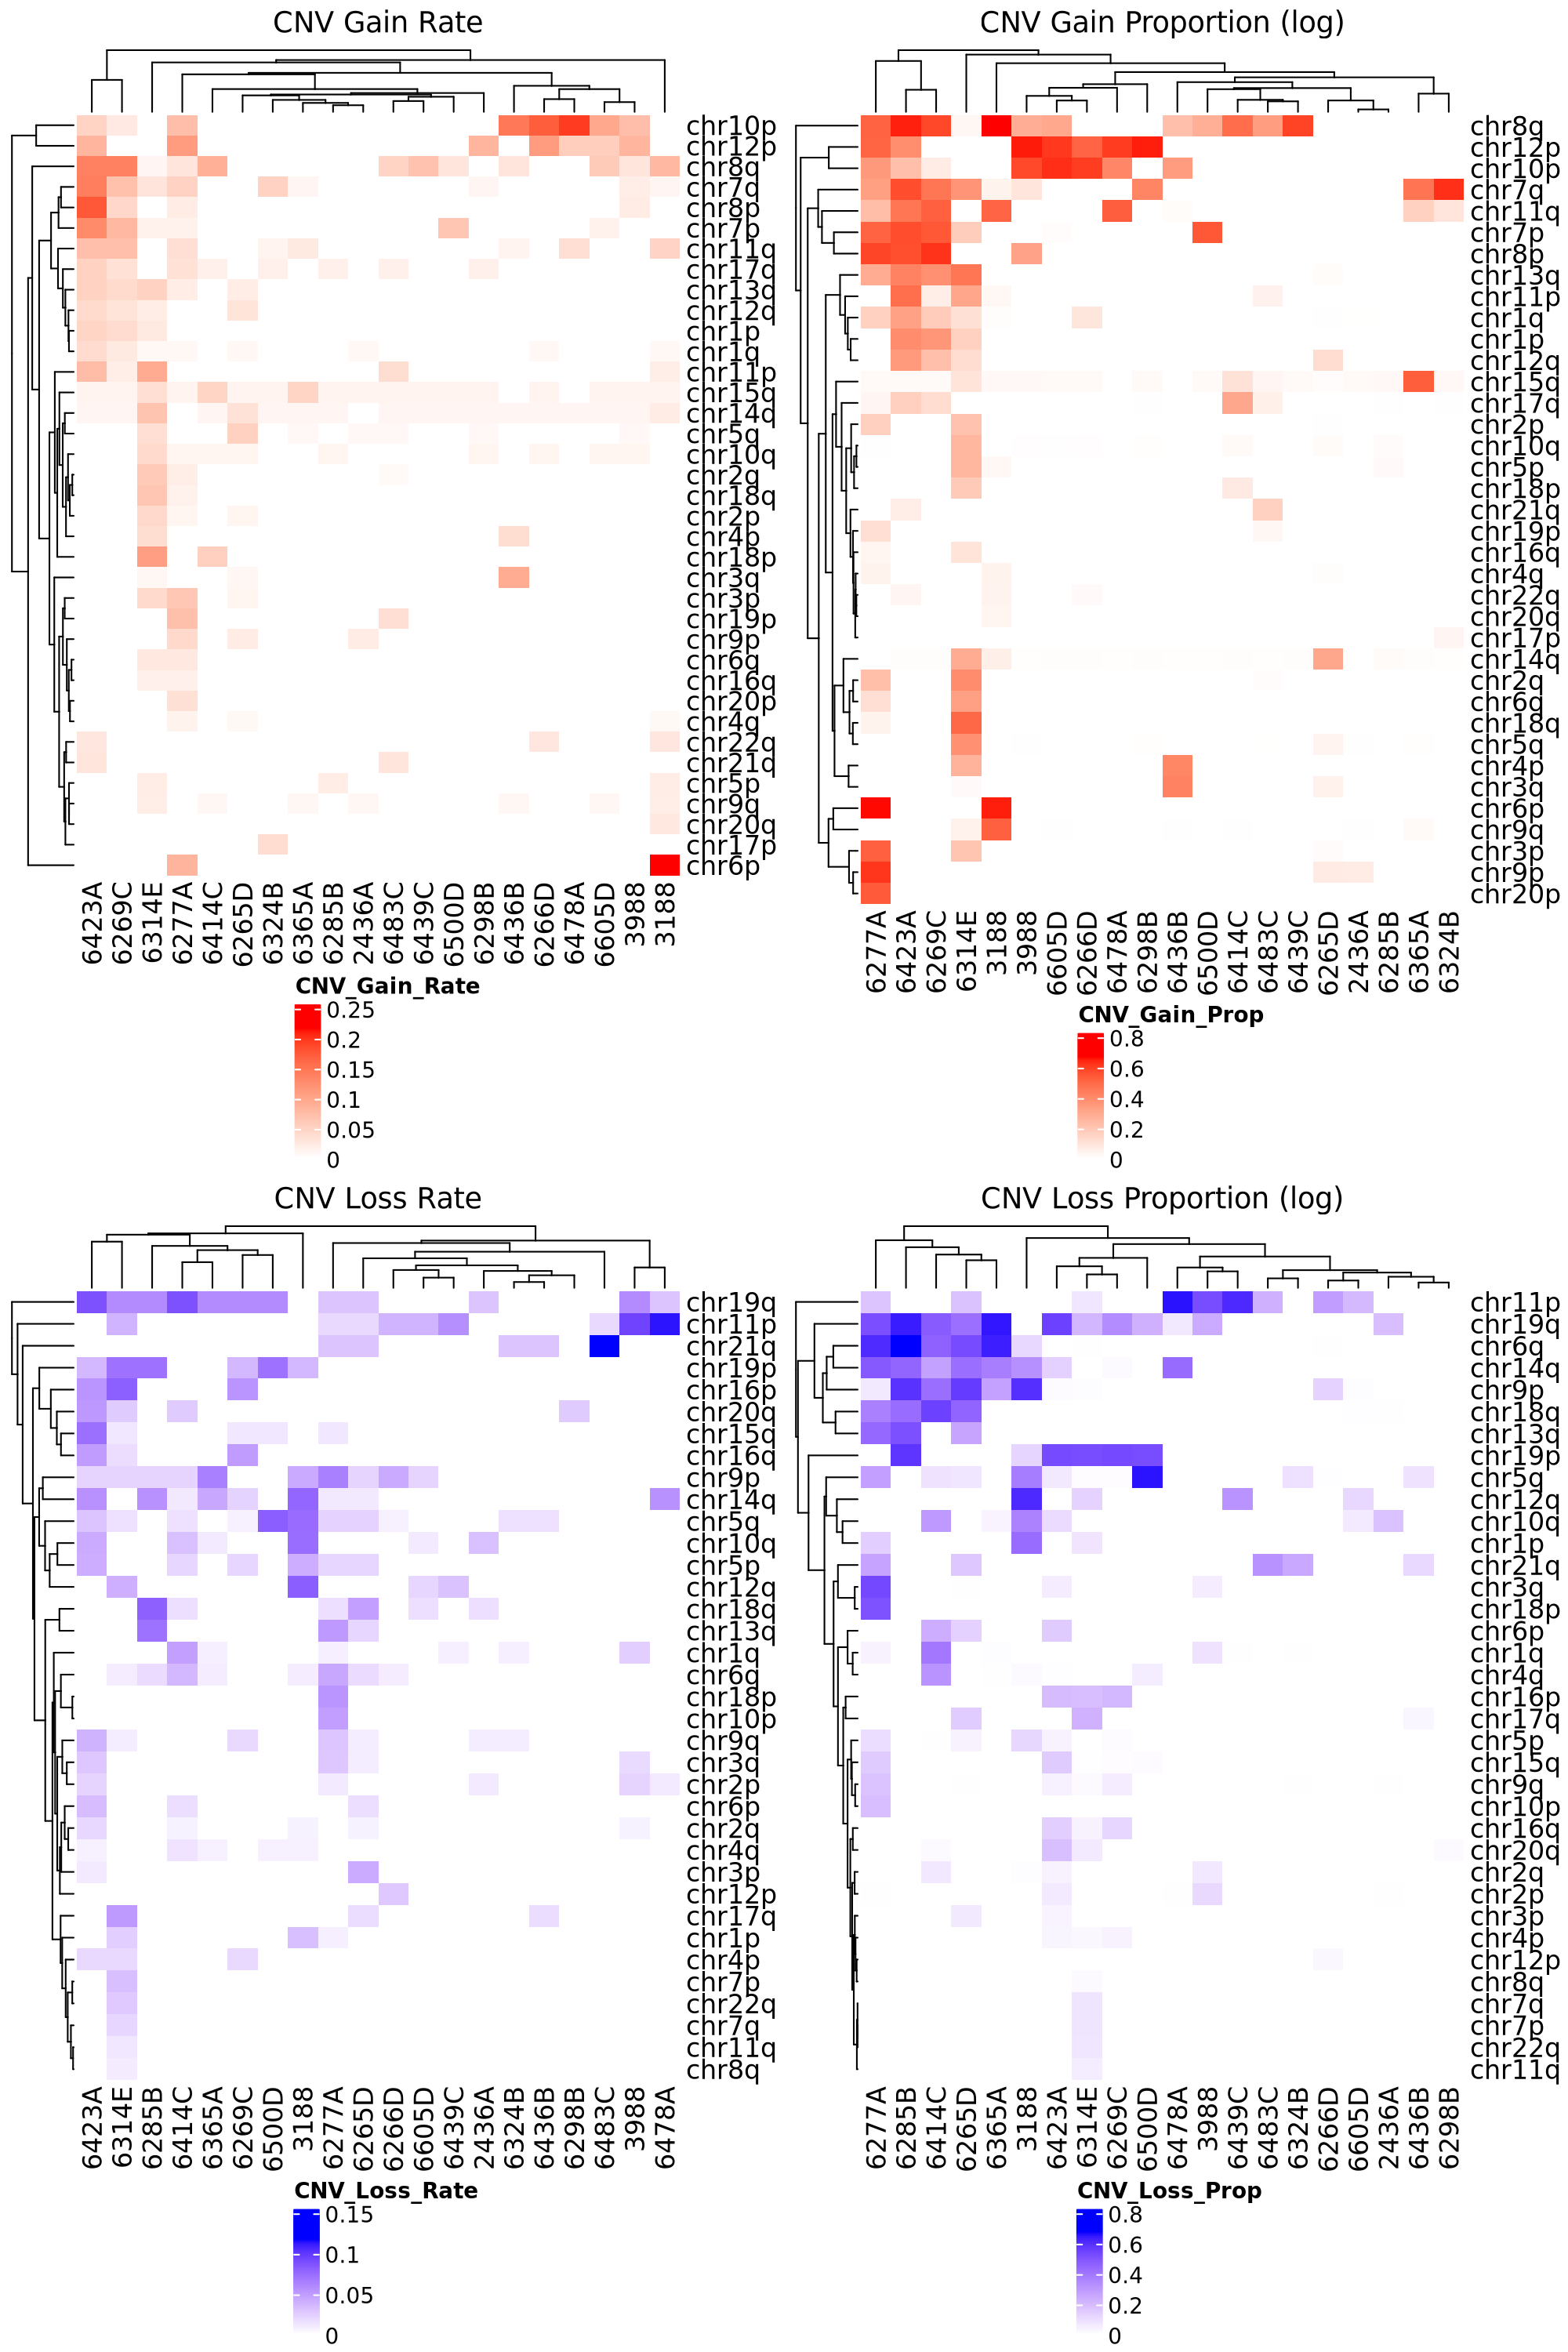

In [46]:
#### log scale for proportions data

library(ComplexHeatmap)
library(circlize)
library(grid)

# Helper: safe color scale function
safe_col_fun <- function(x, colors) {
  rng <- range(x, na.rm = TRUE)
  if (rng[1] == rng[2]) {
    delta <- if (rng[1] == 0) 1 else abs(rng[1]) * 0.5
    rng <- rng + c(-delta, delta)
  }
  colorRamp2(rng, colors)
}

# Set image size for interactive session (Jupyter, RStudio, etc.)
options(repr.plot.width = 10, repr.plot.height = 15, repr.plot.res = 200)

# Define color functions
col_fun_gain_rate <- safe_col_fun(rate_matrices_pq$Gain, c("white", "red"))
col_fun_loss_rate <- safe_col_fun(rate_matrices_pq$Loss, c("white", "blue"))

col_fun_gain_prop <- safe_col_fun(log(prop_matrices_pq$Gain + 1), c("white", "red"))
col_fun_loss_prop <- safe_col_fun(log(prop_matrices_pq$Loss + 1), c("white", "blue"))

# Create the 4 heatmaps
cnv_heatmaps <- list(
  Heatmap(rate_matrices_pq$Gain, name = "CNV_Gain_Rate", col = col_fun_gain_rate,
          column_title = "CNV Gain Rate", cluster_rows = TRUE, cluster_columns = TRUE),
  Heatmap(log(prop_matrices_pq$Gain + 1), name = "CNV_Gain_Prop", col = col_fun_gain_prop,
          column_title = "CNV Gain Proportion (log)", cluster_rows = TRUE, cluster_columns = TRUE),
  Heatmap(rate_matrices_pq$Loss, name = "CNV_Loss_Rate", col = col_fun_loss_rate,
          column_title = "CNV Loss Rate", cluster_rows = TRUE, cluster_columns = TRUE),
  Heatmap(log(prop_matrices_pq$Loss + 1), name = "CNV_Loss_Prop", col = col_fun_loss_prop,
          column_title = "CNV Loss Proportion (log)", cluster_rows = TRUE, cluster_columns = TRUE)
)

# Draw grid layout: 2 rows × 2 columns
grid.newpage()
pushViewport(viewport(layout = grid.layout(nrow = 2, ncol = 2)))

# Loop through and draw each heatmap
for (i in seq_along(cnv_heatmaps)) {
  row <- ceiling(i / 2)
  col <- ifelse(i %% 2 == 1, 1, 2)
  vp <- viewport(layout.pos.row = row, layout.pos.col = col)
  pushViewport(vp)
  draw(cnv_heatmaps[[i]], newpage = FALSE, heatmap_legend_side = "bottom")
  upViewport()
}


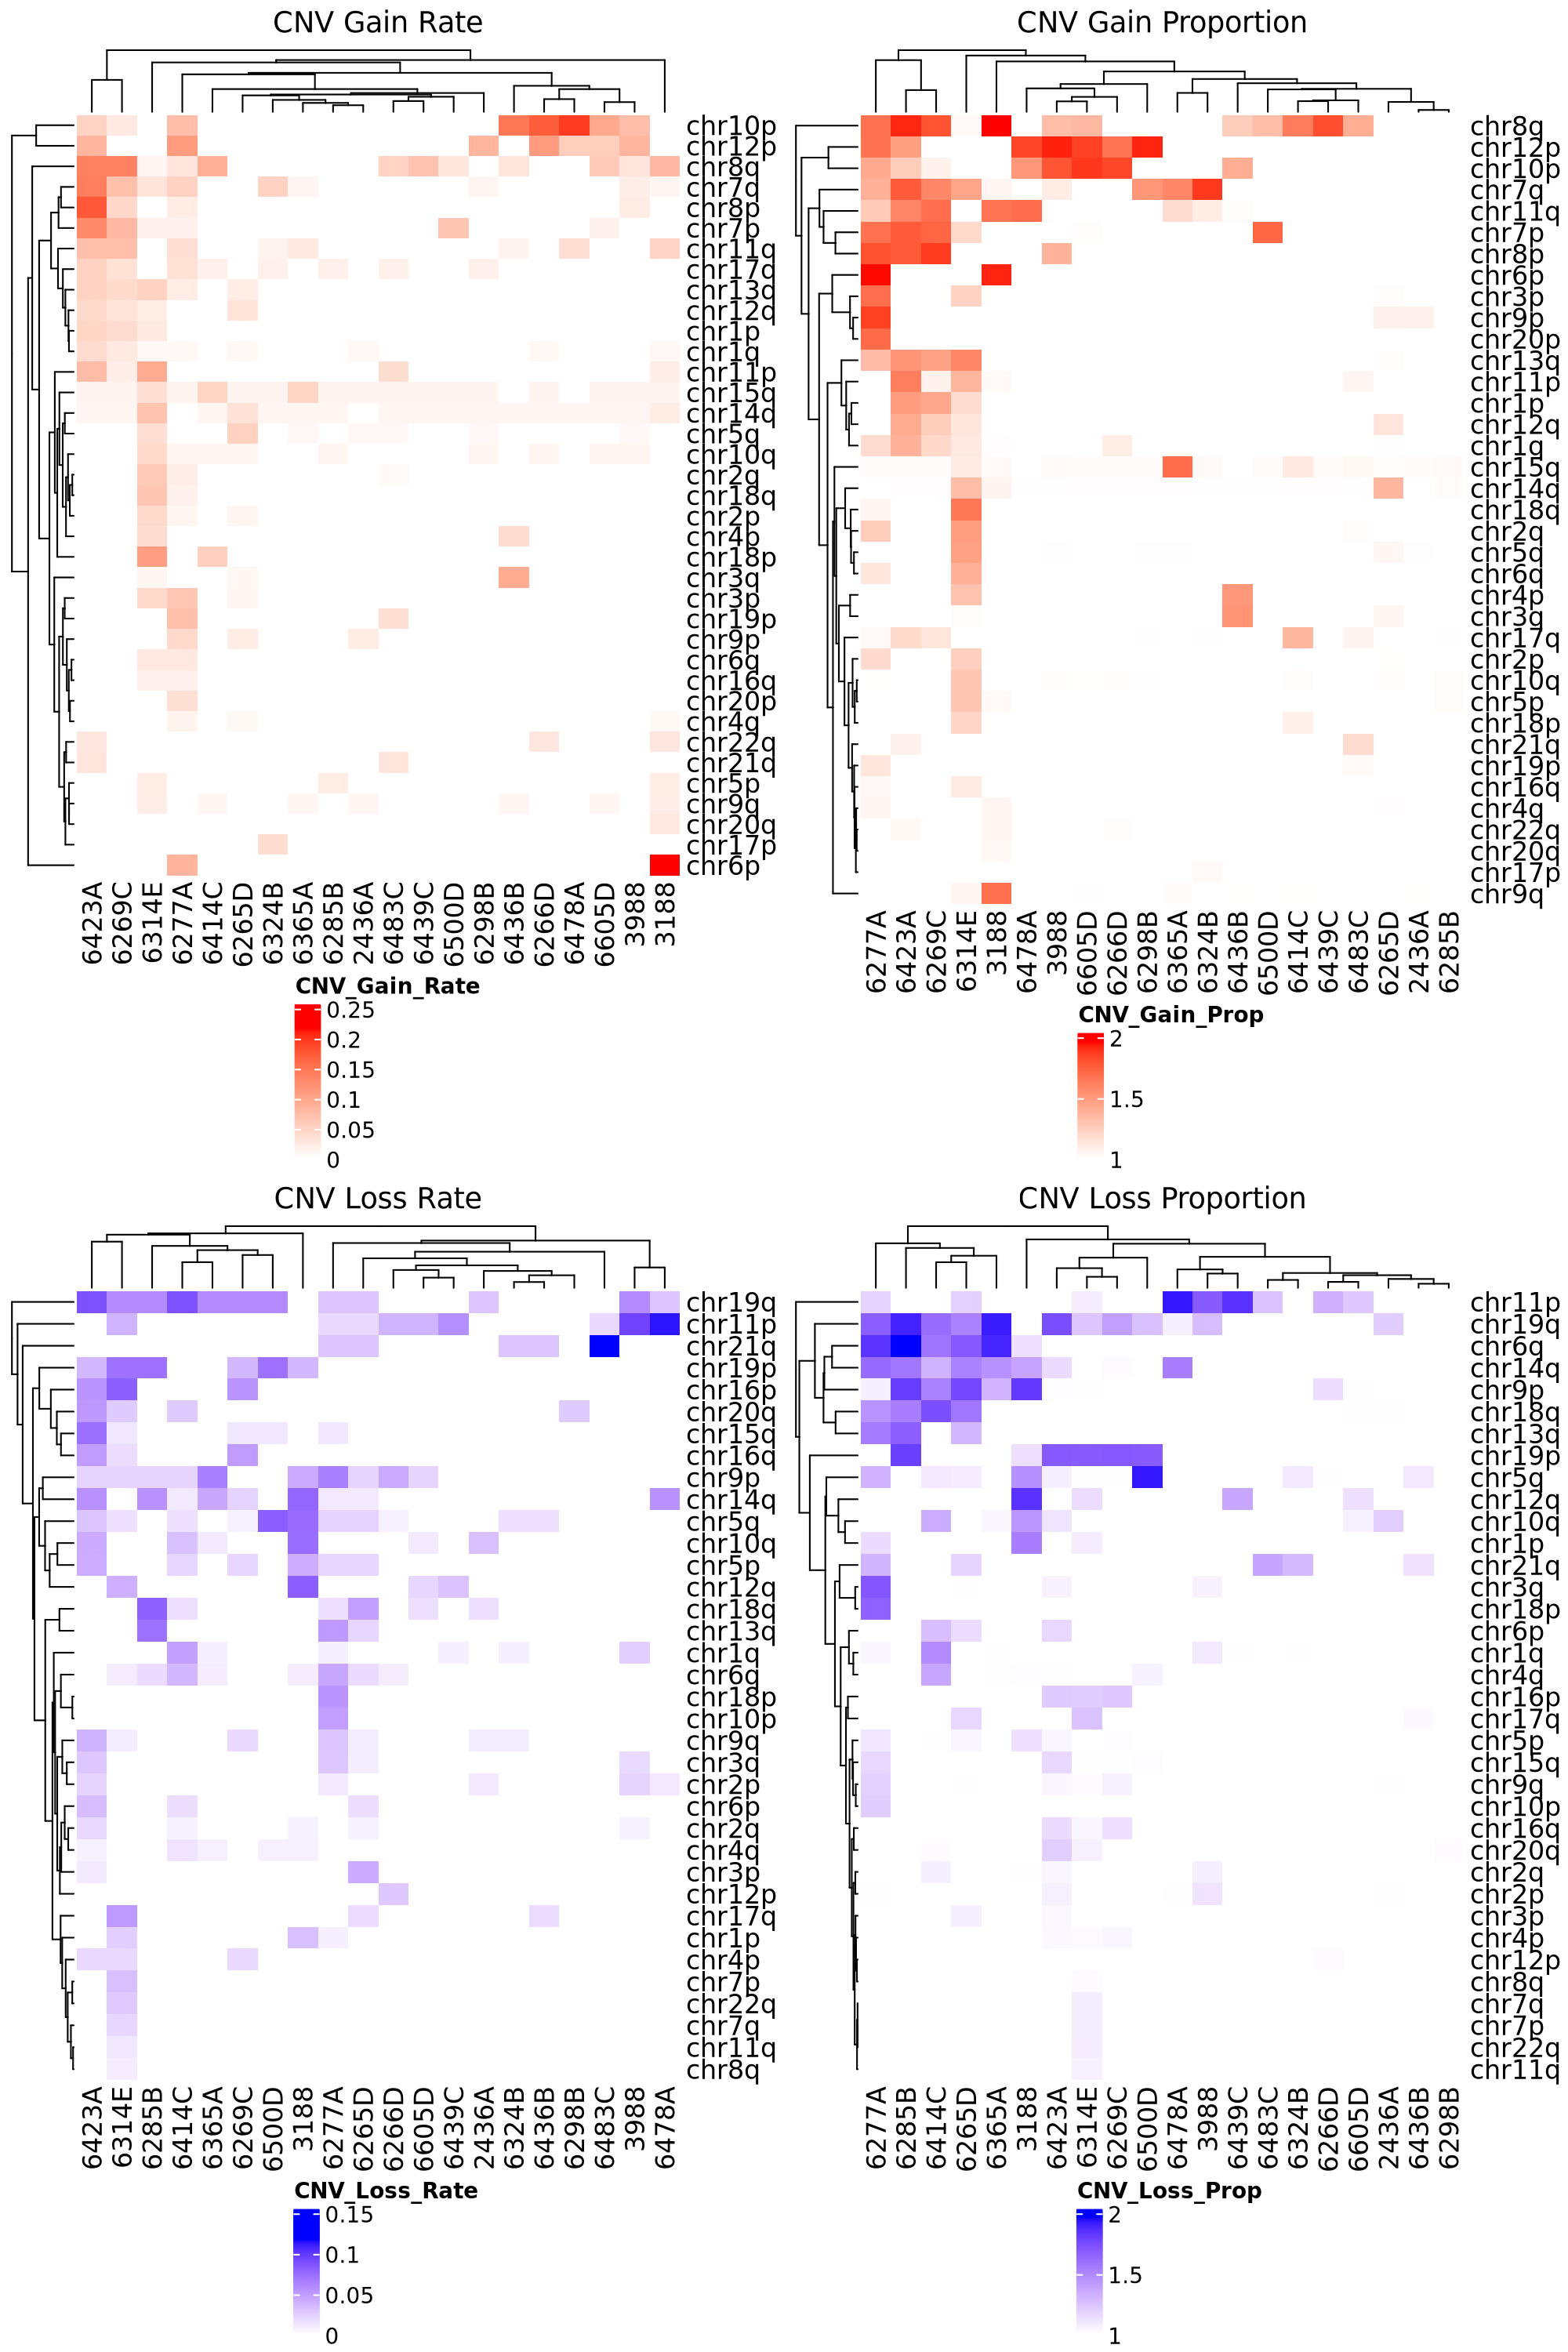

In [47]:
# WITHOUT log scaling

# Helper: safe color scale function
safe_col_fun <- function(x, colors) {
  rng <- range(x, na.rm = TRUE)
  if (rng[1] == rng[2]) {
    delta <- if (rng[1] == 0) 1 else abs(rng[1]) * 0.5
    rng <- rng + c(-delta, delta)
  }
  colorRamp2(rng, colors)
}

# Set image size for interactive session (Jupyter, RStudio, etc.)
options(repr.plot.width = 10, repr.plot.height = 15, repr.plot.res = 200)

# Define color functions
col_fun_gain_rate <- safe_col_fun(rate_matrices_pq$Gain, c("white", "red"))
col_fun_loss_rate <- safe_col_fun(rate_matrices_pq$Loss, c("white", "blue"))

col_fun_gain_prop <- safe_col_fun((prop_matrices_pq$Gain + 1), c("white", "red"))
col_fun_loss_prop <- safe_col_fun((prop_matrices_pq$Loss + 1), c("white", "blue"))

# Create the 4 heatmaps
cnv_heatmaps <- list(
  Heatmap(rate_matrices_pq$Gain, name = "CNV_Gain_Rate", col = col_fun_gain_rate,
          column_title = "CNV Gain Rate", cluster_rows = TRUE, cluster_columns = TRUE),
  Heatmap((prop_matrices_pq$Gain + 1), name = "CNV_Gain_Prop", col = col_fun_gain_prop,
          column_title = "CNV Gain Proportion", cluster_rows = TRUE, cluster_columns = TRUE),
  Heatmap(rate_matrices_pq$Loss, name = "CNV_Loss_Rate", col = col_fun_loss_rate,
          column_title = "CNV Loss Rate", cluster_rows = TRUE, cluster_columns = TRUE),
  Heatmap((prop_matrices_pq$Loss + 1), name = "CNV_Loss_Prop", col = col_fun_loss_prop,
          column_title = "CNV Loss Proportion", cluster_rows = TRUE, cluster_columns = TRUE)
)

# Draw grid layout: 2 rows × 2 columns
grid.newpage()
pushViewport(viewport(layout = grid.layout(nrow = 2, ncol = 2)))

# Loop through and draw each heatmap
for (i in seq_along(cnv_heatmaps)) {
  row <- ceiling(i / 2)
  col <- ifelse(i %% 2 == 1, 1, 2)
  vp <- viewport(layout.pos.row = row, layout.pos.col = col)
  pushViewport(vp)
  draw(cnv_heatmaps[[i]], newpage = FALSE, heatmap_legend_side = "bottom")
  upViewport()
}


In [48]:
# Step 2: Calculate proportion of affected chromosome length
library(tibble)

chromosome_lengths <- tibble(
  chrom = c("chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10",
            "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20",
            "chr21", "chr22"),
  Length = c(248387328, 242696752, 201105948, 193574945, 182045439, 172126628, 160567428, 146259331,
             150617247, 134758134, 135127769, 133324548, 113566686, 101161492, 99753195, 96330374,
             84276897, 80542538, 61707364, 66210255, 45090682, 51324926)
)




In [52]:
library(dplyr)

# Step 1: Summarize total segment length and count per ID and chromosome
cnv_summary <- df_cnv %>%
  mutate(segment_mb = (loc.end - loc.start) / 1e6) %>%
  group_by(ID, chrom, Gain_Loss) %>%
  summarise(
    total_mb = sum(segment_mb),
    cnv_count = n(),
    .groups = "drop"
  )

# Step 2: Chromosome lengths in Mb
chrom_lengths <- tibble(
  chrom = paste0("chr", c(1:22, "X", "Y")),
  len_mb = c(248.96, 242.19, 198.30, 190.21, 181.54, 170.81, 159.35, 145.14, 138.39, 133.80,
             135.09, 133.28, 114.36, 107.04, 101.99, 90.34, 83.26, 80.37, 58.62, 64.44, 46.71, 50.82, 156.04, 57.23)
)

# Step 3: Merge and calculate proportion + rate
cnv_summary <- cnv_summary %>%
  left_join(chrom_lengths, by = "chrom") %>%
  mutate(
    prop_chr = total_mb / len_mb,
    rate_per_mb = cnv_count / len_mb
  )
head(cnv_summary)

ID,chrom,Gain_Loss,total_mb,cnv_count,len_mb,prop_chr,rate_per_mb
<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
2436A,chr1,Gain,0.200151,1,248.96,0.0008039484,0.004016710
2436A,chr1,Neutral,27.820989,1,248.96,0.1117488311,0.004016710
2436A,chr10,Loss,18.621836,3,133.80,0.1391766517,0.022421525
2436A,chr10,Neutral,26.230785,4,133.80,0.1960447309,0.029895366
2436A,chr11,Neutral,3.002850,1,135.09,0.0222285143,0.007402472
2436A,chr12,Neutral,13.812903,4,133.28,0.1036382278,0.030012005


In [53]:
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)

# Filter and pivot to matrices
gain_prop_mat <- cnv_summary %>%
  filter(Gain_Loss == "Gain") %>%
  select(chrom, ID, prop_chr) %>%
  pivot_wider(names_from = ID, values_from = prop_chr, values_fill = 0) %>%
  column_to_rownames("chrom") %>%
  as.matrix()

gain_rate_mat <- cnv_summary %>%
  filter(Gain_Loss == "Gain") %>%
  select(chrom, ID, rate_per_mb) %>%
  pivot_wider(names_from = ID, values_from = rate_per_mb, values_fill = 0) %>%
  column_to_rownames("chrom") %>%
  as.matrix()

loss_prop_mat <- cnv_summary %>%
  filter(Gain_Loss == "Loss") %>%
  select(chrom, ID, prop_chr) %>%
  pivot_wider(names_from = ID, values_from = prop_chr, values_fill = 0) %>%
  column_to_rownames("chrom") %>%
  as.matrix()

loss_rate_mat <- cnv_summary %>%
  filter(Gain_Loss == "Loss") %>%
  select(chrom, ID, rate_per_mb) %>%
  pivot_wider(names_from = ID, values_from = rate_per_mb, values_fill = 0) %>%
  column_to_rownames("chrom") %>%
  as.matrix()


In [54]:
### Scaled with log of proportion

 # Safe color scale function
safe_col_fun <- function(x, colors) {
  rng <- range(x, na.rm = TRUE)
  if (rng[1] == rng[2]) {
    delta <- if (rng[1] == 0) 1 else abs(rng[1]) * 0.5
    rng <- rng + c(-delta, delta)
  }
  colorRamp2(rng, colors)
}

# Set size if using Jupyter or RStudio
options(repr.plot.width = 10, repr.plot.height = 13, repr.plot.res = 200)

# Define color scales
col_fun_gain_rate <- safe_col_fun(gain_rate_mat, c("white", "red"))
col_fun_loss_rate <- safe_col_fun(loss_rate_mat, c("white", "blue"))

col_fun_gain_prop <- safe_col_fun(log(gain_prop_mat + 1), c("white", "red"))
col_fun_loss_prop <- safe_col_fun(log(loss_prop_mat + 1), c("white", "blue"))

# Create the heatmaps
cnv_heatmaps <- list(
  Heatmap(gain_rate_mat, name = "Gain Rate", col = col_fun_gain_rate,
          column_title = "Gain Rate", cluster_rows = TRUE, cluster_columns = TRUE),
  Heatmap(log(gain_prop_mat + 1), name = "Gain Prop", col = col_fun_gain_prop,
          column_title = "Gain Proportion (log scaled)", cluster_rows = TRUE, cluster_columns = TRUE),
  Heatmap(loss_rate_mat, name = "Loss Rate", col = col_fun_loss_rate,
          column_title = "Loss Rate", cluster_rows = 2, cluster_columns = TRUE),
  Heatmap(log(loss_prop_mat + 1), name = "Loss Prop", col = col_fun_loss_prop,
          column_title = "Loss Proportion (log scaled)", cluster_rows = TRUE, cluster_columns = TRUE)
)

# 2x2 layout
grid.newpage()
pushViewport(viewport(layout = grid.layout(2, 2)))

for (i in seq_along(cnv_heatmaps)) {
  row <- ceiling(i / 2)
  col <- ifelse(i %% 2 == 1, 1, 2)
  vp <- viewport(layout.pos.row = row, layout.pos.col = col)
  pushViewport(vp)
  draw(cnv_heatmaps[[i]], newpage = FALSE, heatmap_legend_side = "bottom")
  upViewport()
}


ERROR: Error: `cluster_rows` should be a logical value, a clustering function or a
clustering object.


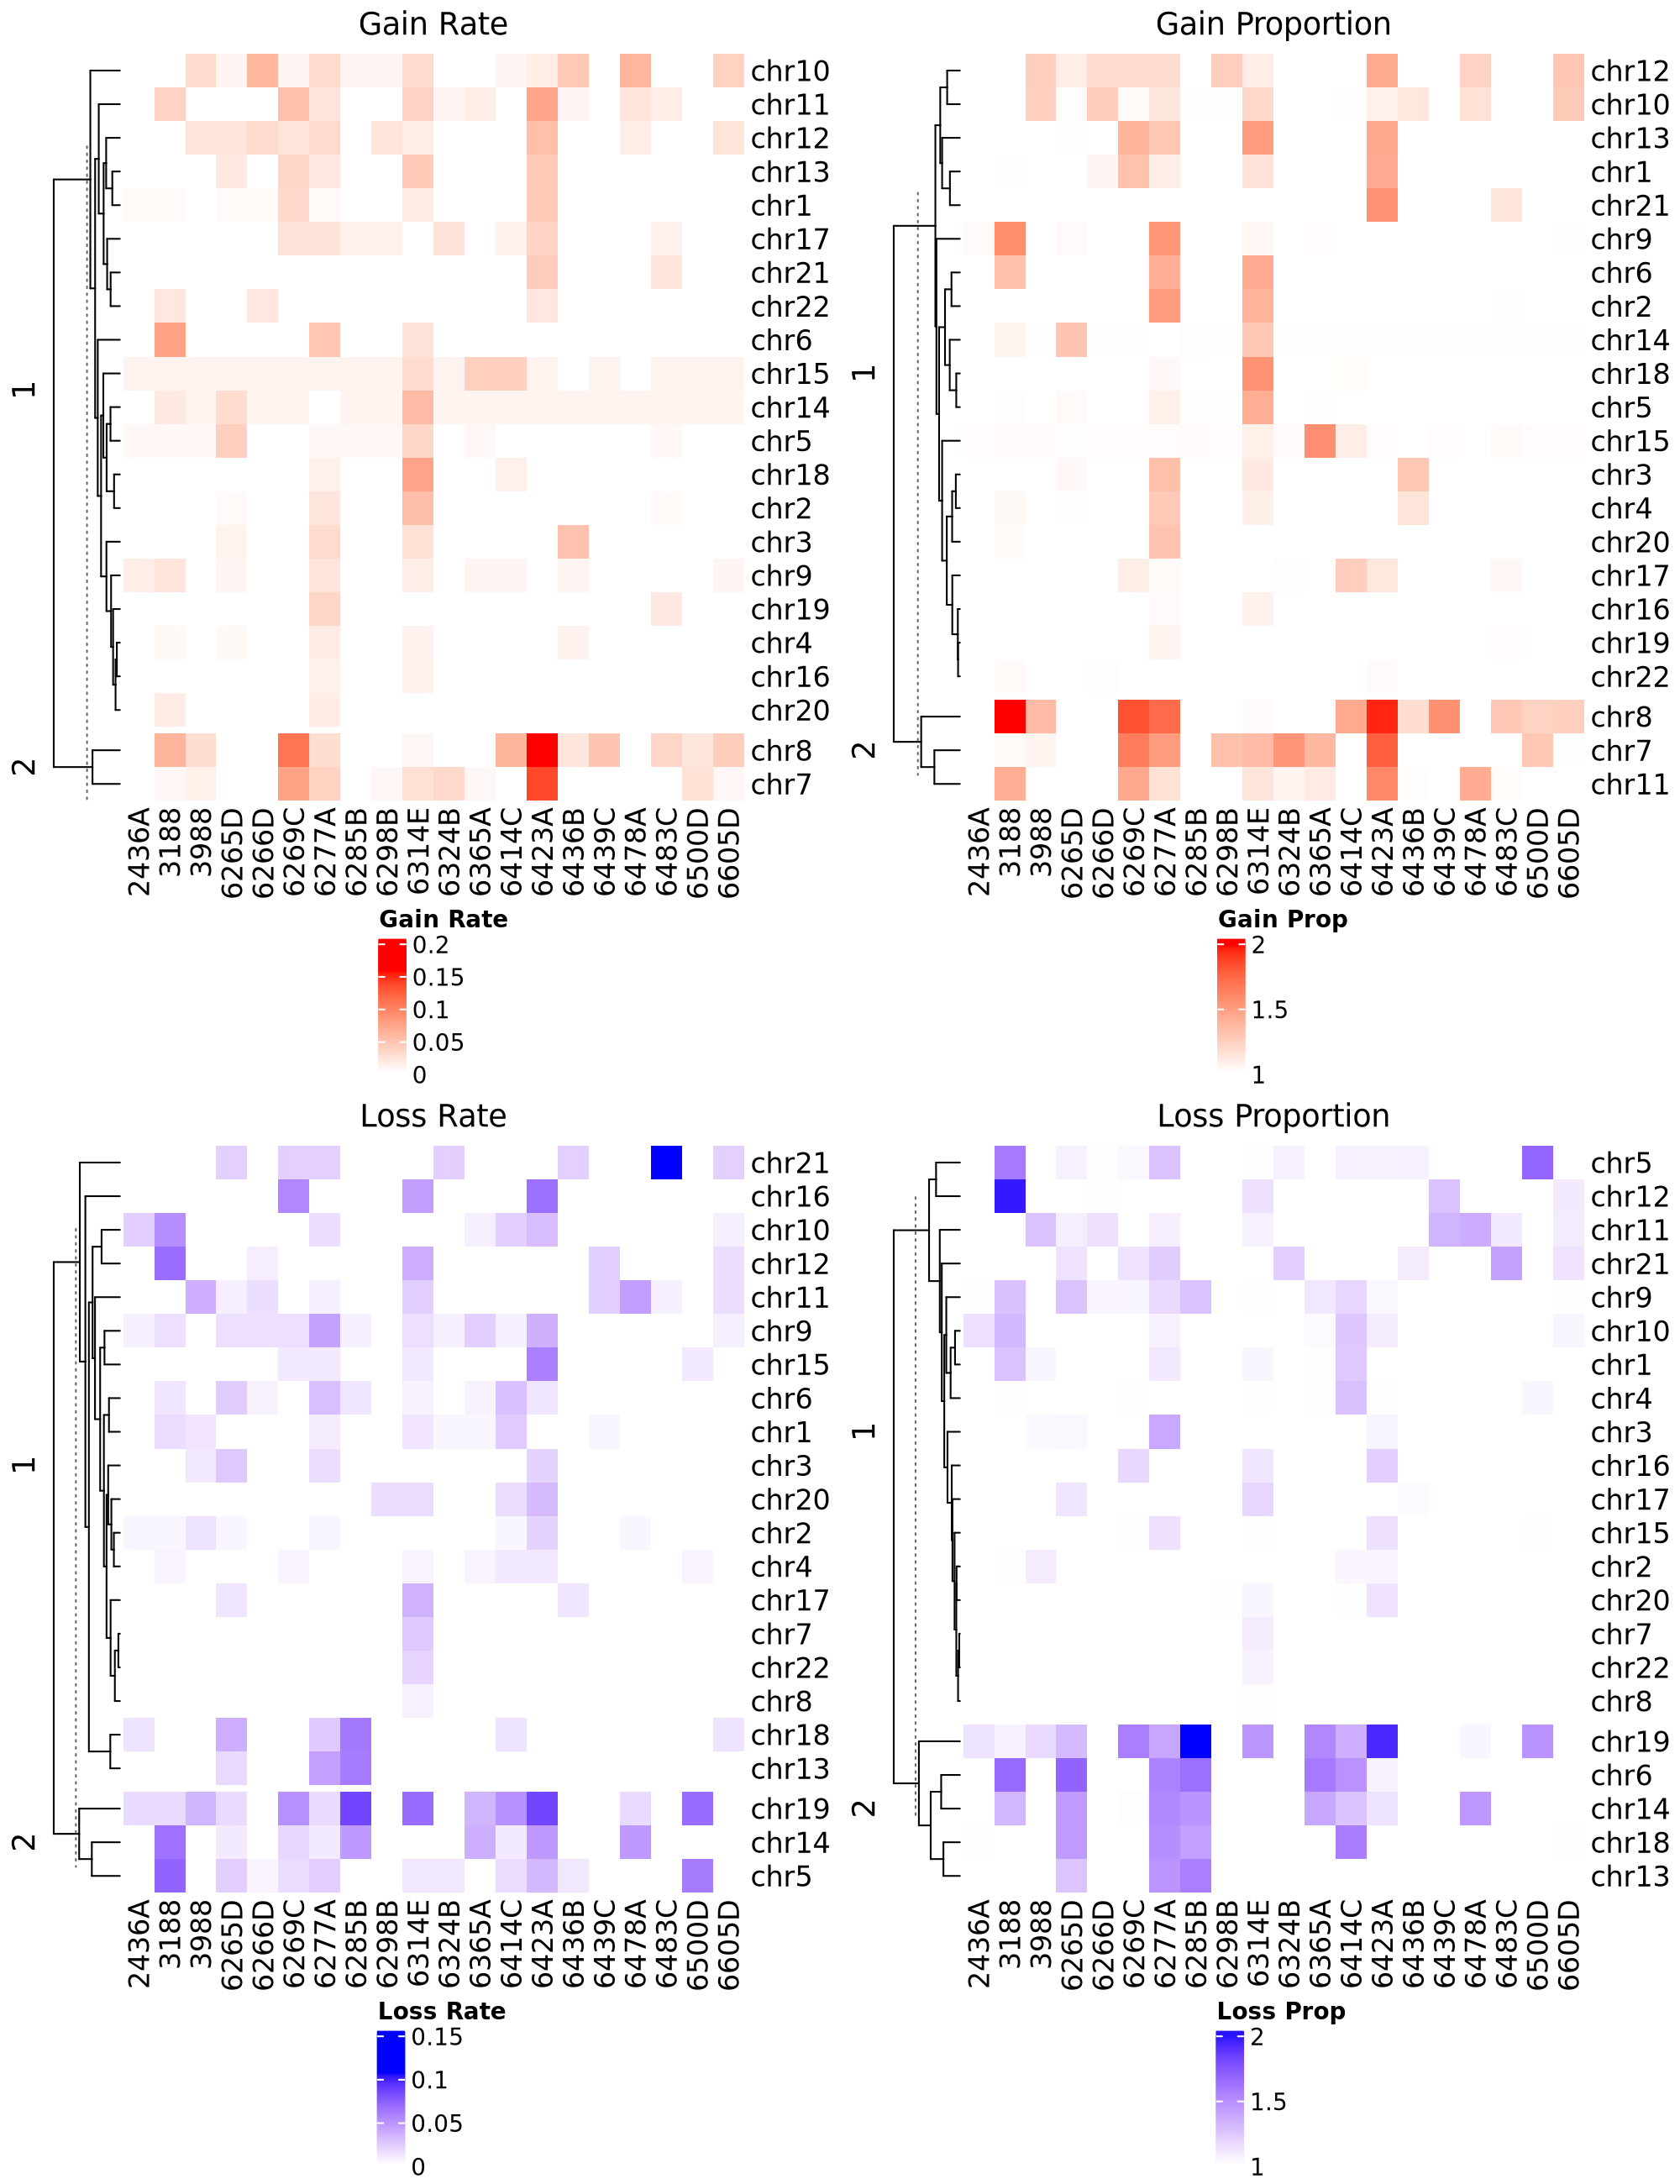

In [58]:
### without log scaled

 # Safe color scale function
safe_col_fun <- function(x, colors) {
  rng <- range(x, na.rm = TRUE)
  if (rng[1] == rng[2]) {
    delta <- if (rng[1] == 0) 1 else abs(rng[1]) * 0.5
    rng <- rng + c(-delta, delta)
  }
  colorRamp2(rng, colors)
}

# Set size if using Jupyter or RStudio
options(repr.plot.width = 10, repr.plot.height = 13, repr.plot.res = 200)

# Define color scales
col_fun_gain_rate <- safe_col_fun(gain_rate_mat, c("white", "red"))
col_fun_loss_rate <- safe_col_fun(loss_rate_mat, c("white", "blue"))

col_fun_gain_prop <- safe_col_fun((gain_prop_mat + 1), c("white", "red"))
col_fun_loss_prop <- safe_col_fun((loss_prop_mat + 1), c("white", "blue"))

# Create the heatmaps
cnv_heatmaps <- list(
  Heatmap(gain_rate_mat, name = "Gain Rate", col = col_fun_gain_rate,
          column_title = "Gain Rate", cluster_rows = TRUE, cluster_columns = FALSE, row_km = 2),
  Heatmap((gain_prop_mat + 1), name = "Gain Prop", col = col_fun_gain_prop,
          column_title = "Gain Proportion", cluster_rows = TRUE,  cluster_columns = FALSE, row_km = 2),
  Heatmap(loss_rate_mat, name = "Loss Rate", col = col_fun_loss_rate,
          column_title = "Loss Rate", cluster_rows = TRUE,  cluster_columns = FALSE, row_km = 2),
  Heatmap((loss_prop_mat + 1), name = "Loss Prop", col = col_fun_loss_prop,
          column_title = "Loss Proportion", cluster_rows = TRUE,  cluster_columns = FALSE, row_km = 2)
)

# 2x2 layout
grid.newpage()
pushViewport(viewport(layout = grid.layout(2, 2)))

for (i in seq_along(cnv_heatmaps)) {
  row <- ceiling(i / 2)
  col <- ifelse(i %% 2 == 1, 1, 2)
  vp <- viewport(layout.pos.row = row, layout.pos.col = col)
  pushViewport(vp)
  draw(cnv_heatmaps[[i]], newpage = FALSE, heatmap_legend_side = "bottom")
  upViewport()
}


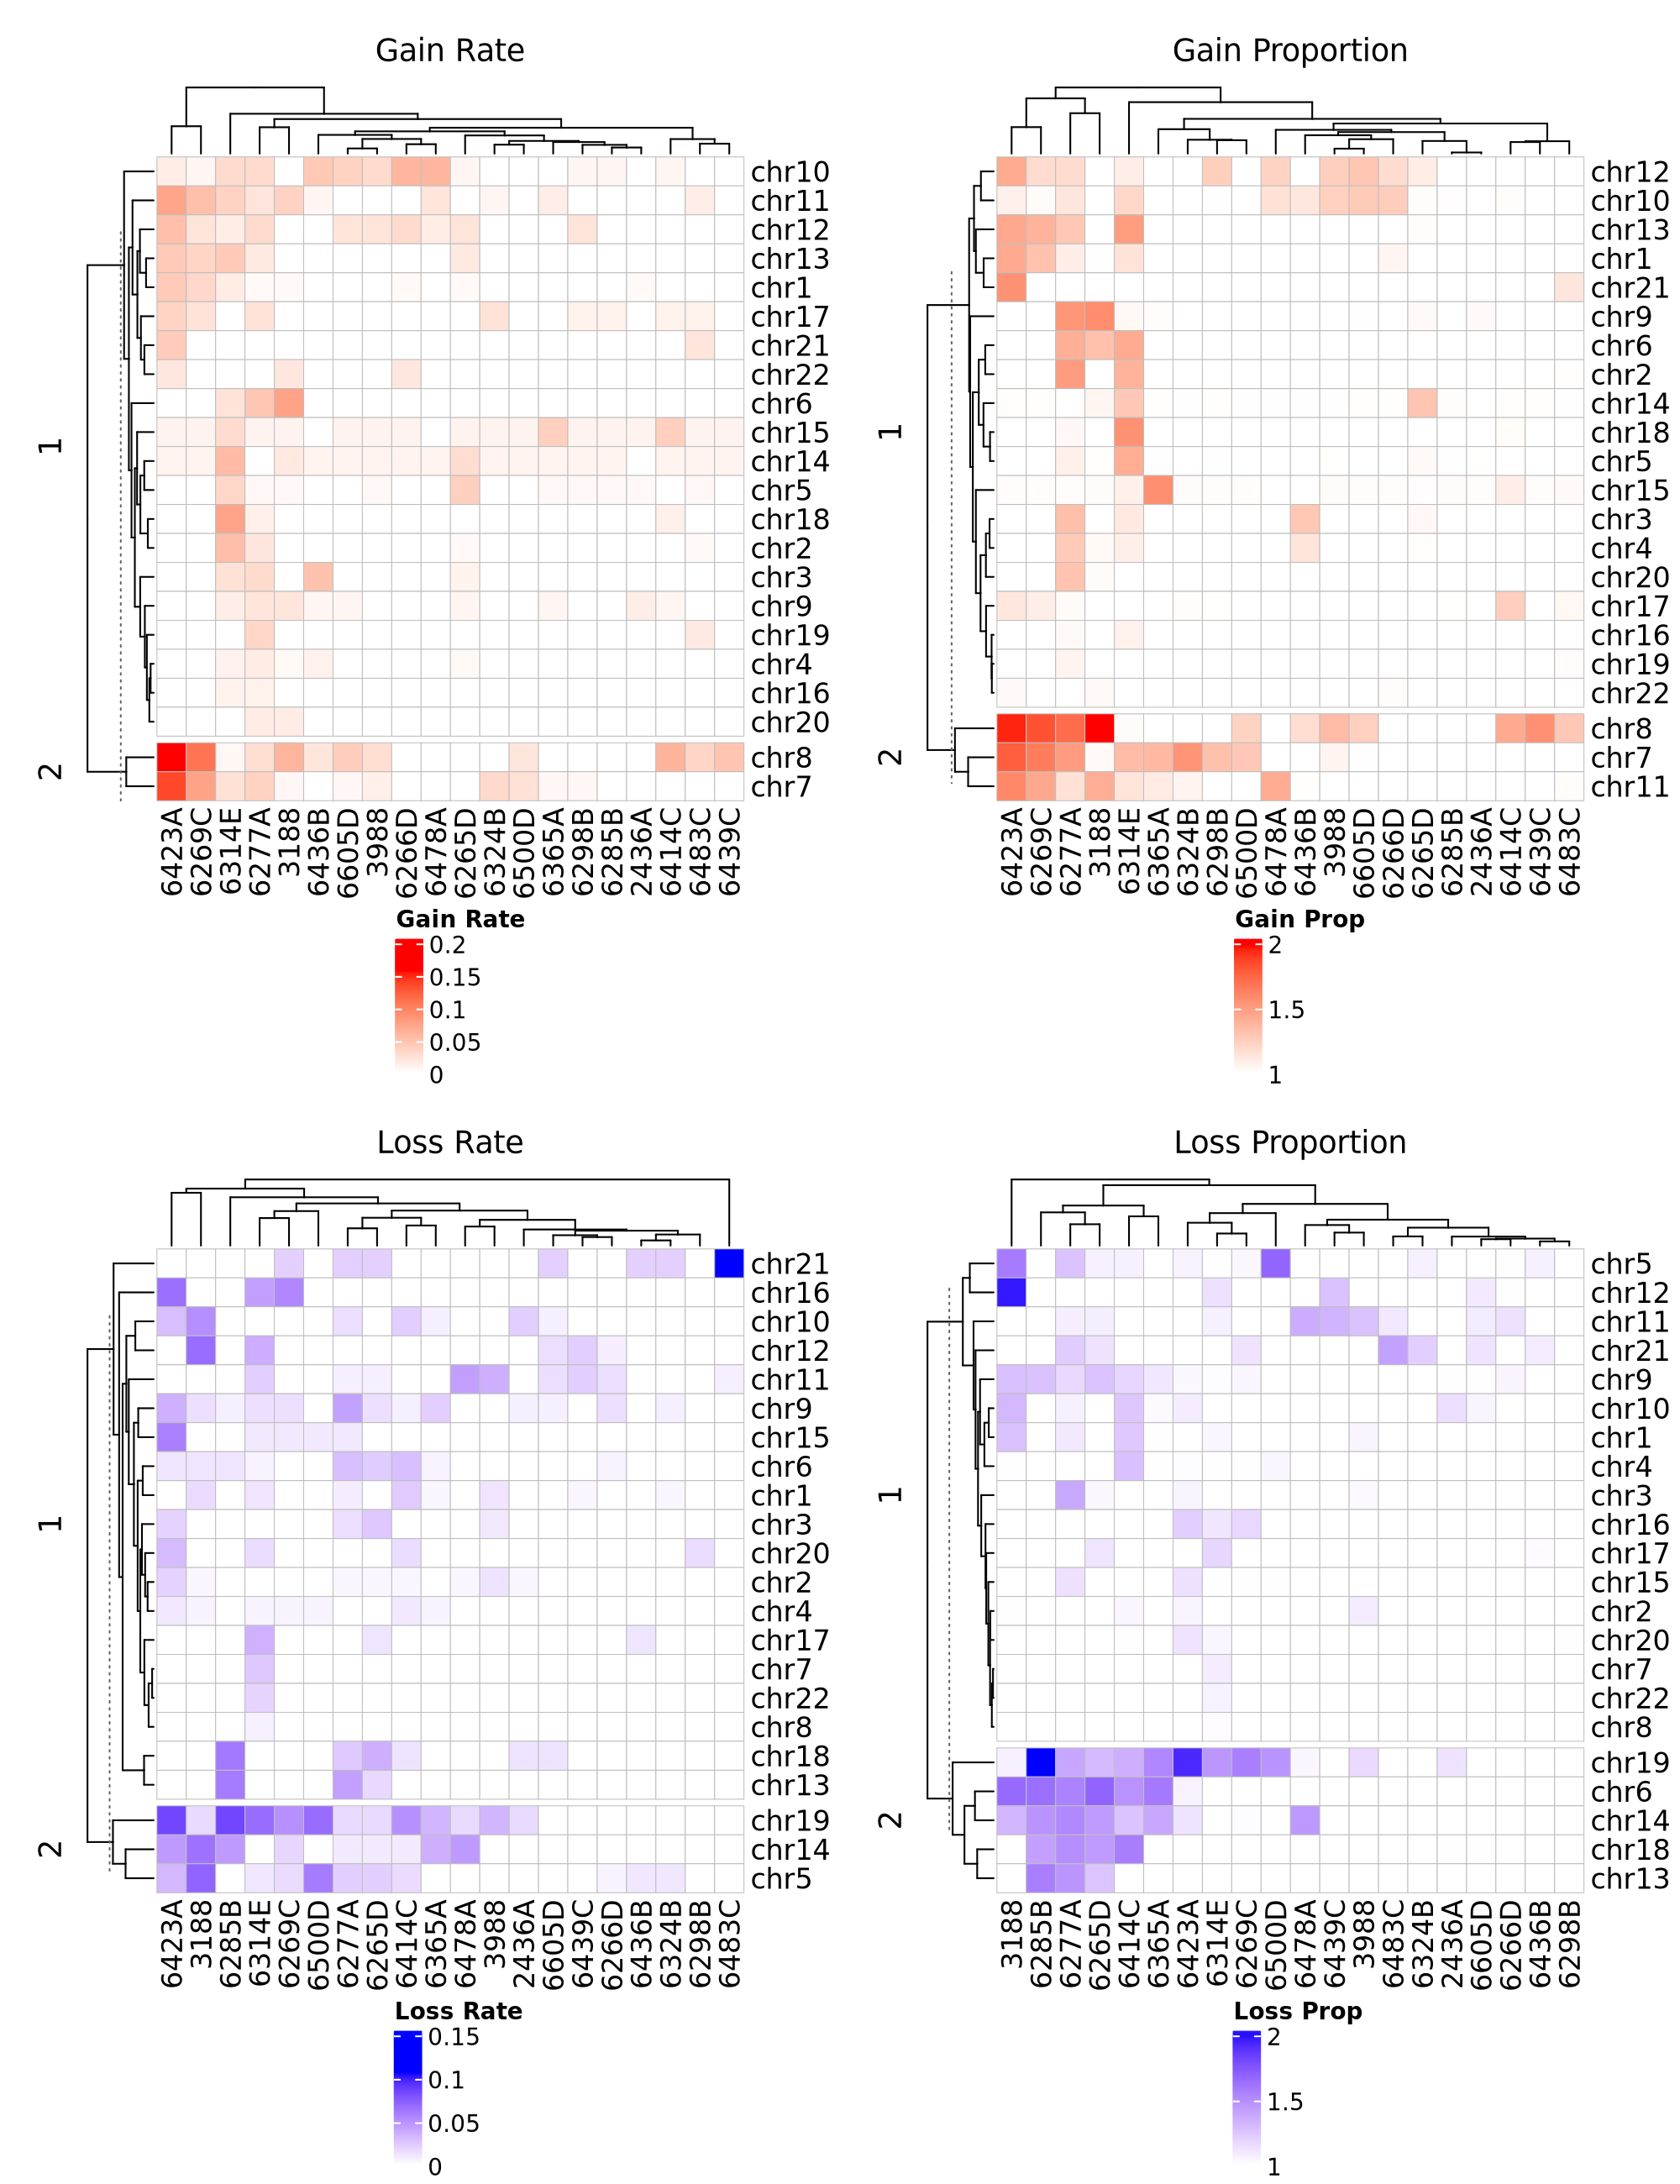

In [85]:
library(ComplexHeatmap)
library(circlize)
library(grid)

# Safe color scale function
safe_col_fun <- function(x, colors) {
  rng <- range(x, na.rm = TRUE)
  if (rng[1] == rng[2]) {
    delta <- if (rng[1] == 0) 1 else abs(rng[1]) * 0.5
    rng <- rng + c(-delta, delta)
  }
  colorRamp2(rng, colors)
}

# Plot dimensions (useful in Jupyter or RStudio)
options(repr.plot.width = 10, repr.plot.height = 13, repr.plot.res = 200)

# Define color functions with saturated ends
col_fun_gain_rate <- safe_col_fun(gain_rate_mat, c("white", "red"))
col_fun_loss_rate <- safe_col_fun(loss_rate_mat, c("white", "blue"))
col_fun_gain_prop <- safe_col_fun((gain_prop_mat + 1), c("white", "red"))
col_fun_loss_prop <- safe_col_fun((loss_prop_mat + 1), c("white", "blue"))

# Create the list of heatmaps with gray tile borders
cnv_heatmaps <- list(
  Heatmap(gain_rate_mat, name = "Gain Rate", col = col_fun_gain_rate,
          column_title = "Gain Rate", cluster_rows = TRUE, cluster_columns = TRUE,
          row_km = 2, na_col = "gray", rect_gp = gpar(col = "gray", lwd = 0.5)),

  Heatmap((gain_prop_mat + 1), name = "Gain Prop", col = col_fun_gain_prop,
          column_title = "Gain Proportion", cluster_rows = TRUE, cluster_columns = TRUE,
          row_km = 2, na_col = "gray", rect_gp = gpar(col = "gray", lwd = 0.5)),

  Heatmap(loss_rate_mat, name = "Loss Rate", col = col_fun_loss_rate,
          column_title = "Loss Rate", cluster_rows = TRUE, cluster_columns = TRUE,
          row_km = 2, na_col = "gray", rect_gp = gpar(col = "gray", lwd = 0.5)),

  Heatmap((loss_prop_mat + 1), name = "Loss Prop", col = col_fun_loss_prop,
          column_title = "Loss Proportion", cluster_rows = TRUE, cluster_columns = TRUE,
          row_km = 2, na_col = "gray", rect_gp = gpar(col = "gray", lwd = 0.5))
)

# Draw heatmaps in a 2x2 grid layout
grid.newpage()
pushViewport(viewport(layout = grid.layout(2, 2)))

for (i in seq_along(cnv_heatmaps)) {
  row <- ceiling(i / 2)
  col <- ifelse(i %% 2 == 1, 1, 2)
  vp <- viewport(layout.pos.row = row, layout.pos.col = col)
  pushViewport(vp)
  draw(cnv_heatmaps[[i]], newpage = FALSE, heatmap_legend_side = "bottom")
  upViewport()
}


In [87]:
# Output file names and directory
output_dir <- "/home/mjehangir/glioma_manuscript/fig1/"
heatmap_titles <- c("gain_rate_heatmap.pdf", "gain_prop_heatmap.pdf", 
                    "loss_rate_heatmap.pdf", "loss_prop_heatmap.pdf")

# Save each heatmap
for (i in seq_along(cnv_heatmaps)) {
  pdf(file.path(output_dir, heatmap_titles[i]), width = 8, height = 8)
  draw(cnv_heatmaps[[i]], newpage = FALSE, heatmap_legend_side = "bottom")
  dev.off()
}

In [56]:
# Step 2: Add Ploidy Group
cnv_summary$Ploidy_Group <- dplyr::case_when(
  cnv_summary$Gain_Loss %in% c("Loss", "Gain") ~ "Aneuploid",
  cnv_summary$Gain_Loss == "Neutral" ~ "Euploid"
)
head(cnv_summary)

ID,chrom,Gain_Loss,total_mb,cnv_count,len_mb,prop_chr,rate_per_mb,Ploidy_Group
<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>
2436A,chr1,Gain,0.200151,1,248.96,0.0008039484,0.004016710,Aneuploid
2436A,chr1,Neutral,27.820989,1,248.96,0.1117488311,0.004016710,Euploid
2436A,chr10,Loss,18.621836,3,133.80,0.1391766517,0.022421525,Aneuploid
2436A,chr10,Neutral,26.230785,4,133.80,0.1960447309,0.029895366,Euploid
2436A,chr11,Neutral,3.002850,1,135.09,0.0222285143,0.007402472,Euploid
2436A,chr12,Neutral,13.812903,4,133.28,0.1036382278,0.030012005,Euploid


In [29]:
library(circlize)

# Define color scales
rate_color <- colorRamp2(c(0, max(rate_aneuploid, rate_euploid, na.rm = TRUE)), c("white", "brown"))
prop_color <- colorRamp2(c(0, max(prop_aneuploid, prop_euploid, na.rm = TRUE)), c("white", "orange"))


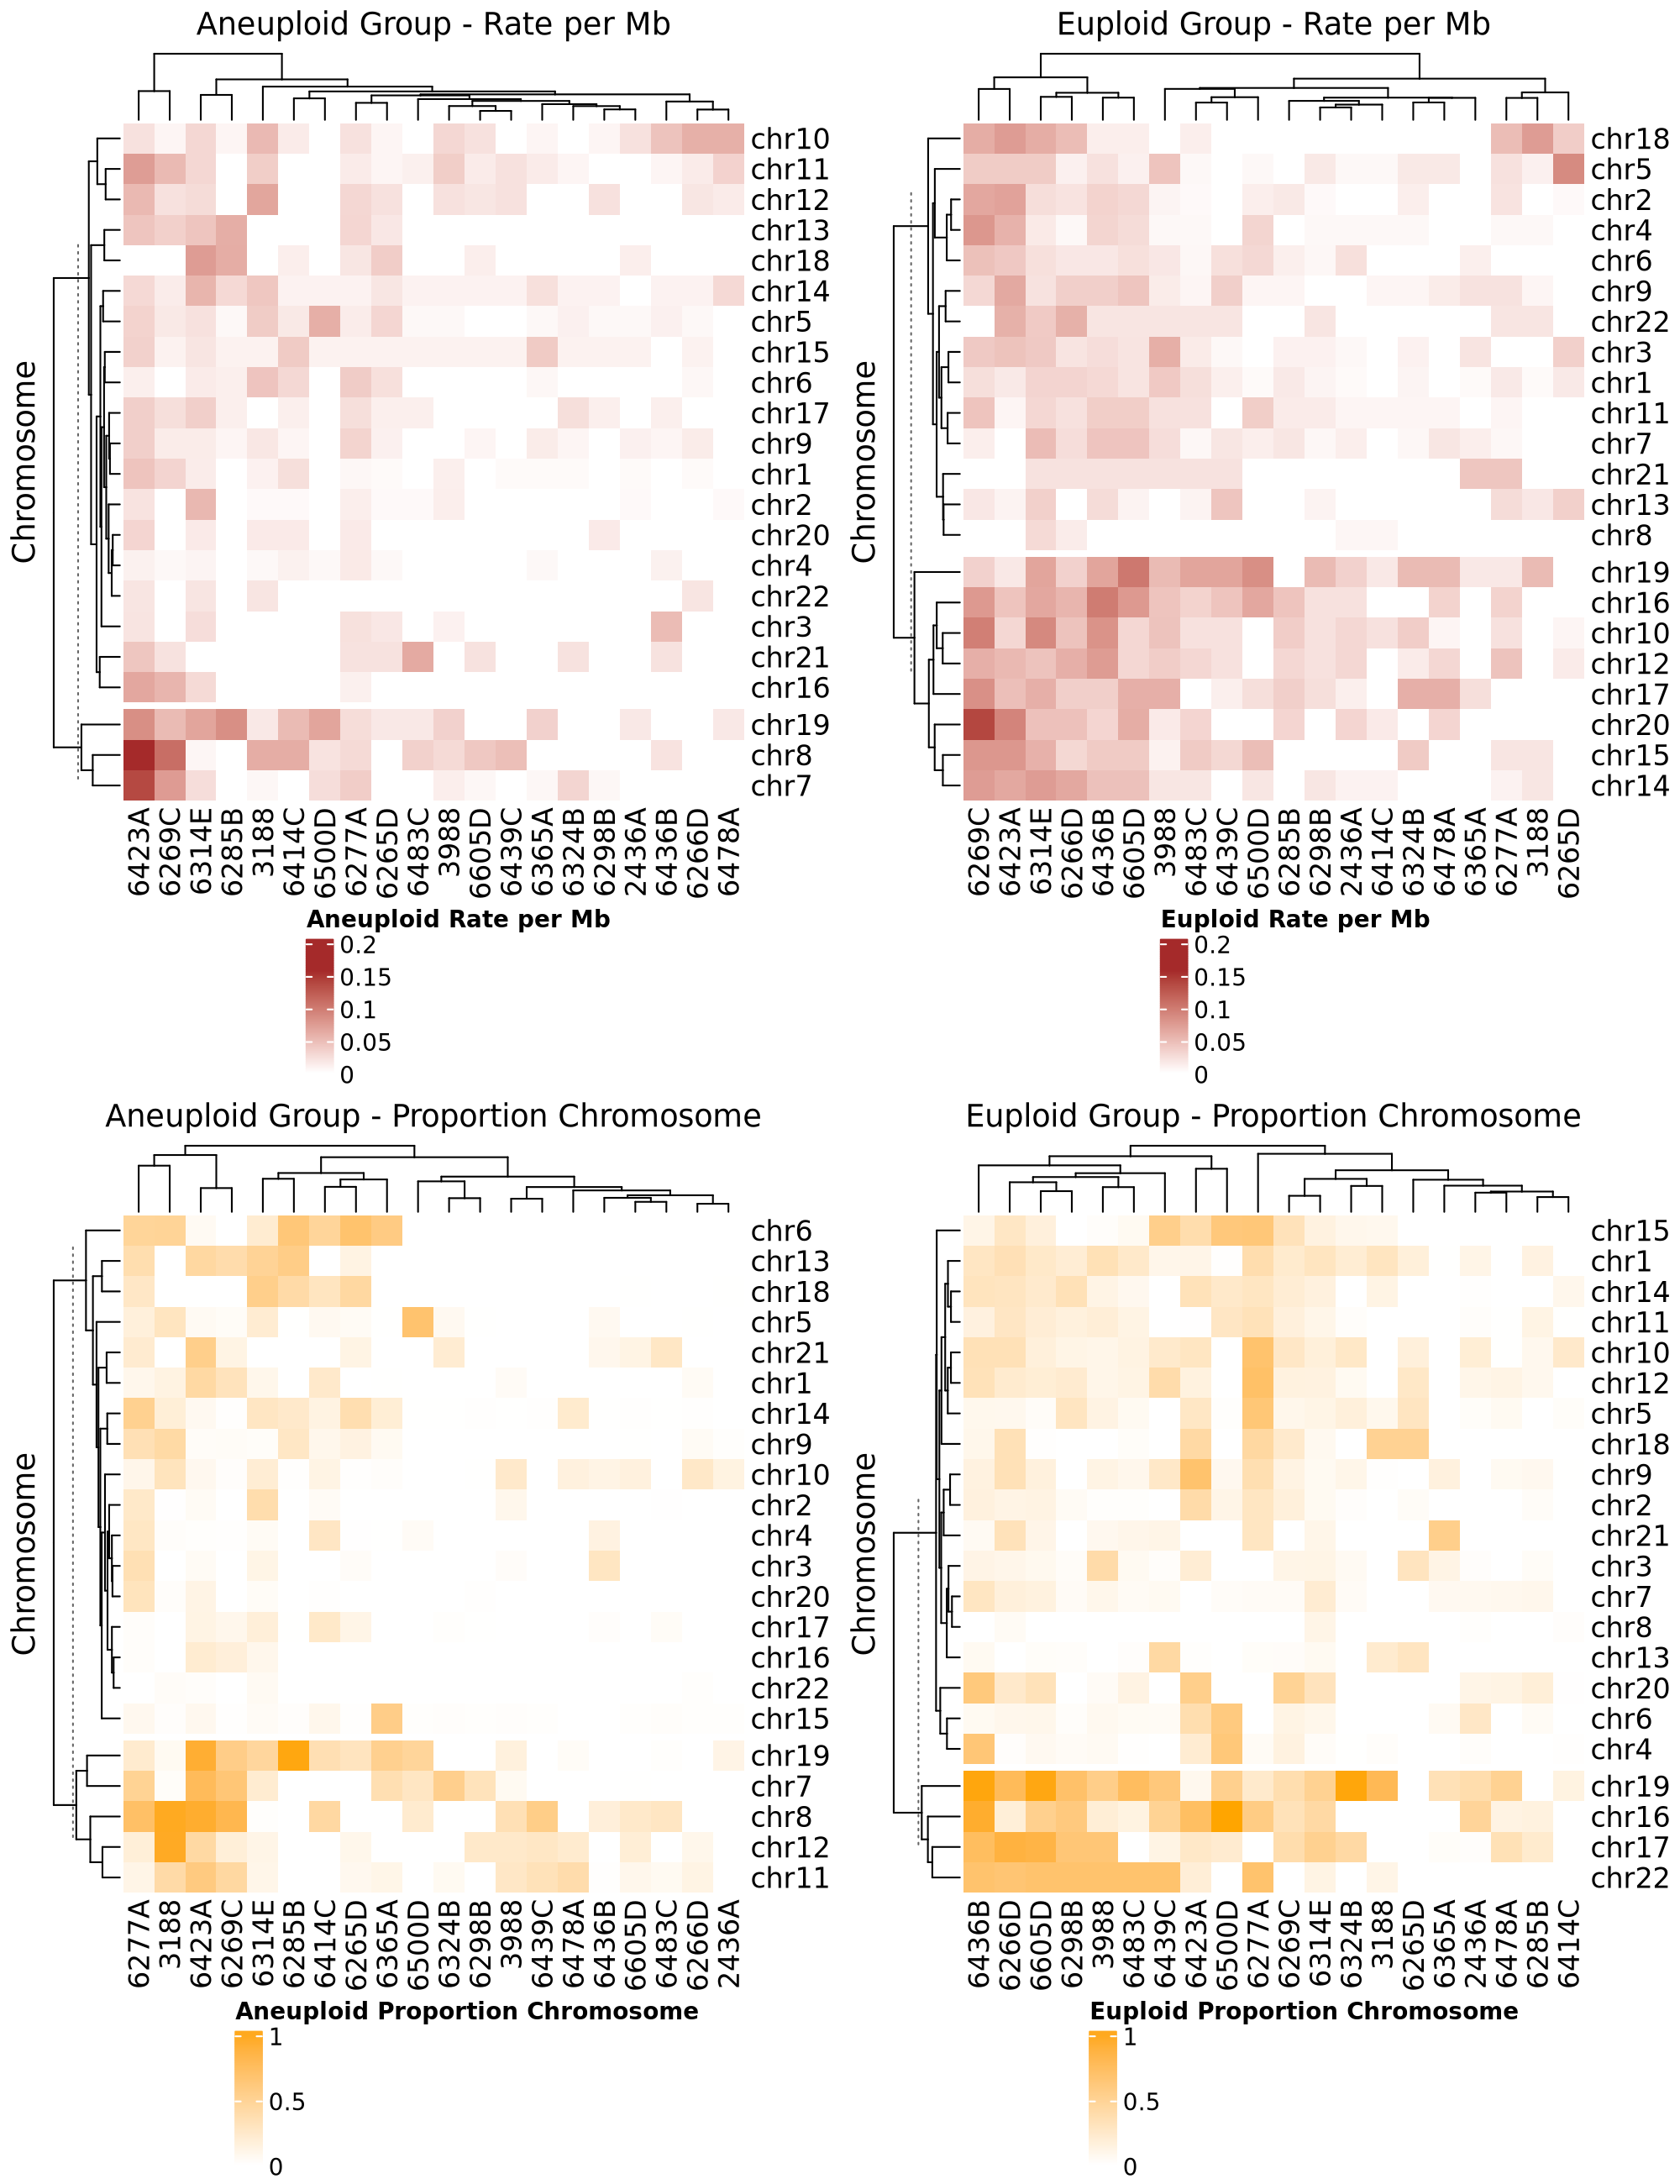

In [31]:


# Step 1: Aggregate the data
cnv_summary_aggregated <- cnv_summary %>%
  group_by(ID, chrom, Ploidy_Group) %>%
  summarise(rate_per_mb = mean(rate_per_mb, na.rm = TRUE),
            prop_chr = mean(prop_chr, na.rm = TRUE), .groups = 'drop')

# Step 2: Separate Aneuploid and Euploid groups
cnv_aneuploid <- cnv_summary_aggregated %>% filter(Ploidy_Group == "Aneuploid")
cnv_euploid <- cnv_summary_aggregated %>% filter(Ploidy_Group == "Euploid")

# Step 3: Prepare matrices
rate_aneuploid <- cnv_aneuploid %>%
  select(ID, chrom, rate_per_mb) %>%
  spread(key = ID, value = rate_per_mb) %>%
  column_to_rownames("chrom") %>%
  as.matrix()

prop_aneuploid <- cnv_aneuploid %>%
  select(ID, chrom, prop_chr) %>%
  spread(key = ID, value = prop_chr) %>%
  column_to_rownames("chrom") %>%
  as.matrix()

rate_euploid <- cnv_euploid %>%
  select(ID, chrom, rate_per_mb) %>%
  spread(key = ID, value = rate_per_mb) %>%
  column_to_rownames("chrom") %>%
  as.matrix()

prop_euploid <- cnv_euploid %>%
  select(ID, chrom, prop_chr) %>%
  spread(key = ID, value = prop_chr) %>%
  column_to_rownames("chrom") %>%
  as.matrix()

# Replace NA, NaN, Inf with 0 or another placeholder
rate_aneuploid[!is.finite(rate_aneuploid)] <- 0
prop_aneuploid[!is.finite(prop_aneuploid)] <- 0
rate_euploid[!is.finite(rate_euploid)] <- 0
prop_euploid[!is.finite(prop_euploid)] <- 0
options(repr.plot.width = 10, repr.plot.height = 13, repr.plot.res = 200)

# Step 5: Create heatmaps with row clustering (k=2) and no column clustering
heatmap_aneuploid_rate <- Heatmap(rate_aneuploid, name = "Aneuploid Rate per Mb",
                                  col = rate_color,
                                  column_title = "Aneuploid Group - Rate per Mb",
                                  row_title = "Chromosome",
                                  row_km = 2,
                                  cluster_columns = TRUE)

heatmap_aneuploid_prop <- Heatmap(prop_aneuploid, name = "Aneuploid Proportion Chromosome",
                                  col = prop_color,
                                  column_title = "Aneuploid Group - Proportion Chromosome",
                                  row_title = "Chromosome",
                                  row_km = 2,
                                  cluster_columns = TRUE)

heatmap_euploid_rate <- Heatmap(rate_euploid, name = "Euploid Rate per Mb",
                                col = rate_color,
                                column_title = "Euploid Group - Rate per Mb",
                                row_title = "Chromosome",
                                row_km = 2,
                                cluster_columns = TRUE)

heatmap_euploid_prop <- Heatmap(prop_euploid, name = "Euploid Proportion Chromosome",
                                col = prop_color,
                                column_title = "Euploid Group - Proportion Chromosome",
                                row_title = "Chromosome",
                                row_km = 2,
                                cluster_columns = TRUE)

# Step 6: Plot all 4 heatmaps in a 2x2 grid
cnv_heatmaps <- list(heatmap_aneuploid_rate, heatmap_euploid_rate,
                     heatmap_aneuploid_prop, heatmap_euploid_prop)

grid.newpage()
pushViewport(viewport(layout = grid.layout(2, 2)))

for (i in seq_along(cnv_heatmaps)) {
  row <- ceiling(i / 2)
  col <- ifelse(i %% 2 == 1, 1, 2)
  vp <- viewport(layout.pos.row = row, layout.pos.col = col)
  pushViewport(vp)
  draw(cnv_heatmaps[[i]], newpage = FALSE, heatmap_legend_side = "bottom")
  upViewport()
}
